# Customer Churn Prediction
## 1. Imports

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
)


## 2. Load Data

In [90]:
df = pd.read_csv("customer_churn_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (440833, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


## 3. Null Value Check

In [91]:
print("Total nulls:", df.isnull().sum().sum())
null_pct = df.isnull().any(axis=1).sum() / len(df) * 100
print(f"Rows with nulls: {null_pct:.2f}%")
df.isnull().sum()

Total nulls: 12
Rows with nulls: 0.00%


CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [92]:
# Drop nulls (safe when < 5%)
df = df.dropna()
print("Nulls after drop:", df.isnull().sum().sum())

Nulls after drop: 0


## 4. Basic EDA

In [93]:
# Check for duplicates
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()


Duplicates: 0


In [94]:
# Drop non-feature column
df = df.drop(columns=["CustomerID"])
print("Columns:", df.columns.tolist())

Columns: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64


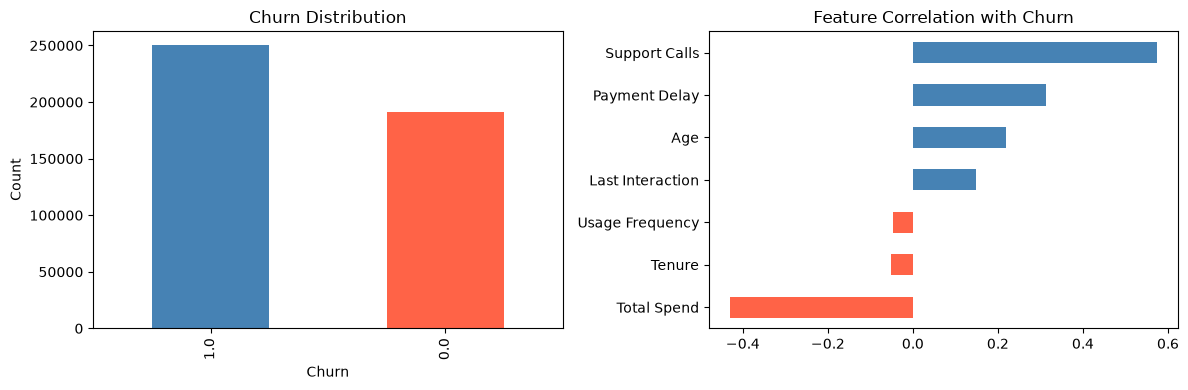

In [95]:
# Class distribution
churn_pct = df["Churn"].value_counts(normalize=True)
print(churn_pct)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn bar chart
df["Churn"].value_counts().plot(
    kind="bar", ax=axes[0], color=["steelblue", "tomato"]
)
axes[0].set_title("Churn Distribution")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")

# Correlation with Churn
corr = df.corr(numeric_only=True)["Churn"].drop("Churn").sort_values()
corr.plot(
    kind="barh", ax=axes[1],
    color=["tomato" if v < 0 else "steelblue" for v in corr]
)
axes[1].set_title("Feature Correlation with Churn")

plt.tight_layout()
plt.show()

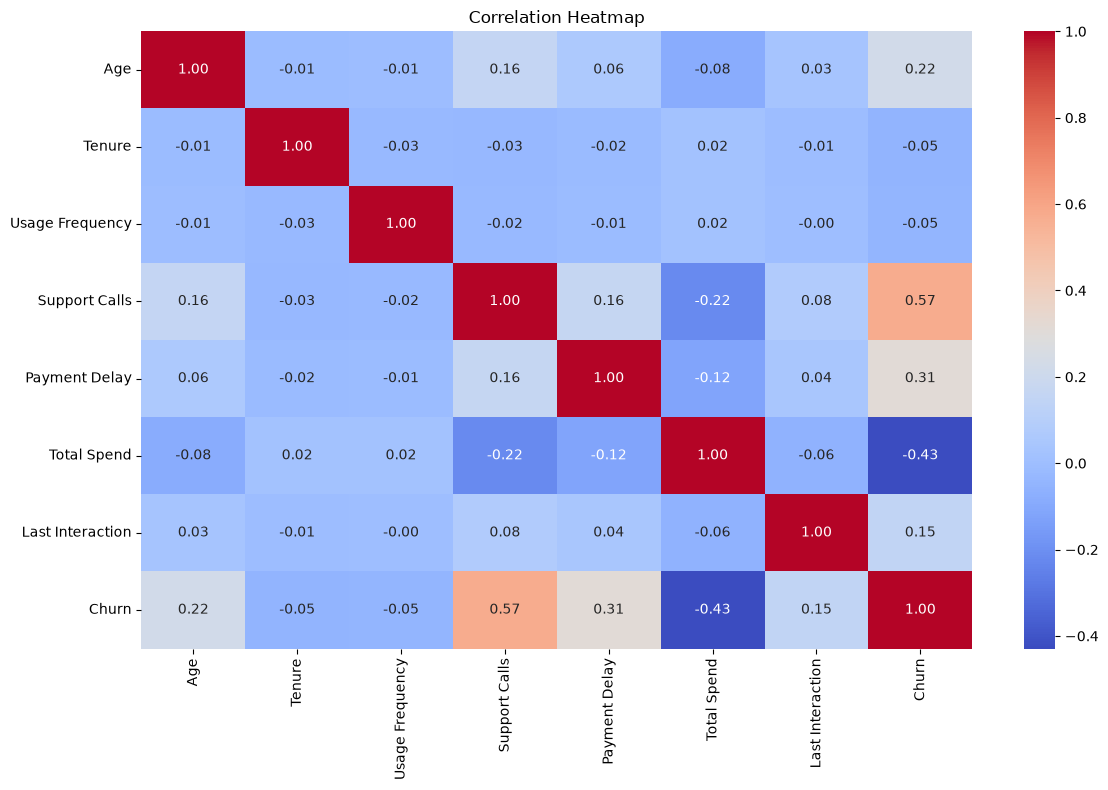

In [96]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 5. Feature Engineering & Encoding

In [97]:
# Binary encode Gender
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})


In [98]:
# Separate features and target BEFORE encoding
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Train/Test split FIRST  (stratify preserves class ratio)
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", x_train.shape, " | Test size:", x_test.shape)

Train size: (352665, 10)  | Test size: (88167, 10)


In [99]:



# One-Hot Encode AFTER splitting  (fit only on train data)
cat_cols = ["Subscription Type", "Contract Length"]
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

encoded_train = encoder.fit_transform(x_train[cat_cols])  # fit + transform
encoded_test  = encoder.transform(x_test[cat_cols])       # transform only

encoded_cols = encoder.get_feature_names_out(cat_cols)

# Build encoded DataFrames (keep index aligned)
x_train_enc = pd.DataFrame(encoded_train, columns=encoded_cols, index=x_train.index)
x_test_enc  = pd.DataFrame(encoded_test,  columns=encoded_cols, index=x_test.index)

# Drop original categorical columns and concatenate encoded ones
x_train = x_train.drop(columns=cat_cols)
x_test  = x_test.drop(columns=cat_cols)
x_train = pd.concat([x_train, x_train_enc], axis=1)
x_test  = pd.concat([x_test,  x_test_enc],  axis=1)

print("Features after encoding:", x_train.columns.tolist())

Features after encoding: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Subscription Type_Basic', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Annual', 'Contract Length_Monthly', 'Contract Length_Quarterly']


In [100]:
# Scale features  (fit on train only — no leakage)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)
print("x_train_scaled shape:", x_train_scaled.shape)

x_train_scaled shape: (352665, 14)


## 6. Model Training

In [101]:
# Random Forest with class_weight='balanced' to handle imbalance
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
model.fit(x_train_scaled, y_train)
print("Training complete.")

Training complete.


## 7. Evaluation

In [102]:
y_pred  = model.predict(x_test_scaled)
y_proba = model.predict_proba(x_test_scaled)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Not Churned", "Churned"]))

Accuracy : 99.94%
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

 Not Churned       1.00      1.00      1.00     38167
     Churned       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churned", "Churned"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Feature Importances
feat_imp = pd.Series(
    model.feature_importances_, index=x_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind="bar", color="steelblue")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

## 8. Save Model Artifacts

In [ ]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(model,   "../models/model.pkl")
joblib.dump(scaler,  "../models/scaler.pkl")
joblib.dump(encoder, "../models/encoder.pkl")

print("Saved: model.pkl  scaler.pkl  encoder.pkl  ->  models/ folder")